# Linear Regression with PyTorch  
## A one-hour physics-first notebook

<div style="padding: 1rem; border-radius: 14px; background: linear-gradient(90deg, #eef6ff, #f8f2ff); border: 1px solid #d8e6ff;">
<b>Story for today:</b> we have a simple physics experiment. A spring is used as a force sensor. We stretch it, measure the force, and ask a neural-network style question:
<br><br>
<center><b>Can a machine learn the physical law from noisy experimental data?</b></center>
</div>

The model will be the simplest possible neural network:

$$
\hat y = wx + b.
$$

By the end, students should be able to connect:

- experimental data $\rightarrow$ tensors,
- physical model $\rightarrow$ linear layer,
- least squares $\rightarrow$ mean squared error,
- numerical optimization $\rightarrow$ gradient descent,
- PyTorch implementation $\rightarrow$ `nn.Linear`.

**Suggested timing:** 10 min data + model, 15 min loss/closed form, 20 min gradient descent, 15 min PyTorch implementation.


## 0. Setup

This notebook only needs PyTorch, NumPy, Matplotlib, Plotly, and Jupyter.

If you are running the notebook locally, install the dependencies before starting Jupyter. You can use either pip:

```bash
pip install torch numpy matplotlib plotly jupyter
```

or the provided Conda environment:

```bash
conda env create -f environment.yml
conda activate mlpytorch
```

If you are running on Google Colab or Kaggle, the next cell checks whether the required packages are already installed and installs only the missing ones. On a local machine, it skips automatic installation.


In [53]:
# Optional dependency check for hosted notebook environments.
# Local Jupyter runs skip automatic package installation.
import importlib.util
import os
import subprocess
import sys

AUTO_INSTALL_IN_HOSTED_NOTEBOOKS = True

def module_is_available(module_name):
    try:
        return importlib.util.find_spec(module_name) is not None
    except ModuleNotFoundError:
        return False

IN_COLAB = module_is_available("google.colab")
IN_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ or "KAGGLE_URL_BASE" in os.environ

required_packages = {
    "torch": "torch",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "plotly": "plotly",
}

if AUTO_INSTALL_IN_HOSTED_NOTEBOOKS and (IN_COLAB or IN_KAGGLE):
    missing_packages = [
        pip_name
        for module_name, pip_name in required_packages.items()
        if not module_is_available(module_name)
    ]

    if missing_packages:
        print("Installing missing packages:", ", ".join(missing_packages))
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
    else:
        print("All required packages are already installed.")
else:
    print("Local environment detected; skipping automatic pip installs.")


Local environment detected; skipping automatic pip installs.


### Import libraries and set defaults

This cell loads the Python libraries used throughout the notebook, sets random seeds so the generated data and training results are reproducible, configures a simple plotting style for the figures, and prints the installed PyTorch version.


In [54]:
%matplotlib inline

import math
import random
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Reproducibility
SEED = 5
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# A light plotting style for classroom use
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
})

print(f"PyTorch version: {torch.__version__}")


PyTorch version: 2.5.1


## 1. Physics example: calibrating a spring force sensor

Hooke's law says that the force is approximately proportional to the extension:

$$
F = kx.
$$

Real lab measurements are not perfect. A sensor may also have an offset, and the measurement will be influenced by experimental noise, so we use

$$
F = kx + b + \epsilon,
$$

where:

- $x$ is the spring extension in **m**,
- $F$ is the measured force in **N**,
- $k$ is the spring constant in **N/m**,
- $b$ is a small sensor offset in **N**,
- $\epsilon$ is experimental noise in **N**.



### Generate synthetic spring data

We choose a spring constant of $k = 42\,\mathrm{N/m}$, which is a realistic order of magnitude for a classroom spring. The offset $b = 0.15\,\mathrm{N}$ represents a small sensor bias, and we assume Gaussian noise with standard deviation $\sigma = 0.22\,\mathrm{N}$ represents experimental measurement error.

The dataset has $n = 60$ measurements. The spring is extended from $0.005\,\mathrm{m}$ to $0.120\,\mathrm{m}$ relative to its relaxed length.

In PyTorch, input data is usually stored as a two-dimensional tensor with shape `(number_of_samples, number_of_features)`. Here we have 60 measurements and one feature, the extension $x$, so we reshape the data to `(60, 1)`. The expression `.reshape(-1, 1)` means: keep one column, and let PyTorch infer the number of rows.

The term `noise_sigma * torch.randn(n, 1)` adds Gaussian measurement noise. `torch.randn` has mean 0 and standard deviation 1, so multiplying by `noise_sigma` gives noise with standard deviation $\sigma = 0.22\,\mathrm{N}$.


In [55]:
# True experimental law, hidden from the learner
true_k = 42.0       # N/m
true_b = 0.15       # N
noise_sigma = 0.22  # N
n = 60

# Extension in meters
x = torch.linspace(0.005, 0.120, n).reshape(-1, 1)
y = true_k * x + true_b + noise_sigma * torch.randn(n, 1)

print("x shape:", tuple(x.shape))
print("y shape:", tuple(y.shape))
print(f"True spring constant k = {true_k:.2f} N/m")
print(f"True offset b = {true_b:.3f} N")


x shape: (60, 1)
y shape: (60, 1)
True spring constant k = 42.00 N/m
True offset b = 0.150 N


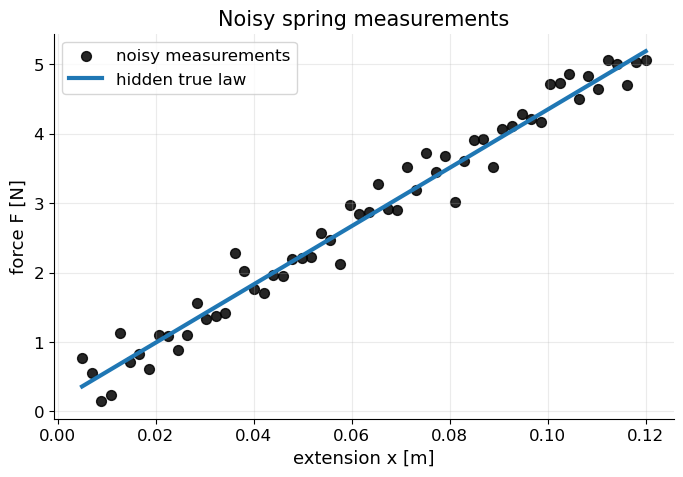

In [56]:
fig, ax = plt.subplots()
ax.scatter(x, y, s=50, color="black", alpha=0.85, label="noisy measurements")
ax.plot(x, true_k*x + true_b, linewidth=3, label="hidden true law")
ax.set_title("Noisy spring measurements")
ax.set_xlabel("extension x [m]")
ax.set_ylabel("force F [N]")
ax.legend()
plt.show()


## 2. The linear regression model

We want to learn a function from data:

$$
x_i \longmapsto y_i.
$$

For one input variable, the model is

$$
\hat y_i = wx_i + b,
$$

where $i=1,\ldots,n$. In vector notation for all data points:

$$
\hat{\mathbf y} = \mathbf{x}w + b\mathbf{1},
$$

where $\mathbf{x}$ is an $(n,1)$ column vector and $\mathbf{1}$ is a column vector of ones. 

For a fit in $d$ dimensions, the model for each data point with features $x_{i1}, x_{i2}, \ldots, x_{id}$ is

$$
\hat y_i = \mathbf{x}_i^\top \mathbf{w} + b,
$$

where a vector of weights $w_1, w_2, \ldots, w_d$ is required.

For $n$ data points in $d$ dimensions, we can write the compact form

$$
\hat{\mathbf y} = \mathbf X \mathbf w + b\mathbf{1},
$$

where $\mathbf X$ is an $(n,d)$ matrix.

As will become clear later, this is in fact a tiny neural network: one linear layer with no activation function.


### Compare a few linear fits chosen by hand

Before training anything, we can try several choices of slope $w$ and intercept $b$ by hand. Each choice gives a different line

$$
\hat y = wx + b.
$$

The mean squared error (MSE) measures how far the model predictions are from the measurements:

$$
\mathrm{MSE} = \frac{1}{n}\sum_{i=1}^n (\hat y_i - y_i)^2.
$$

A smaller MSE means the line fits the data better.


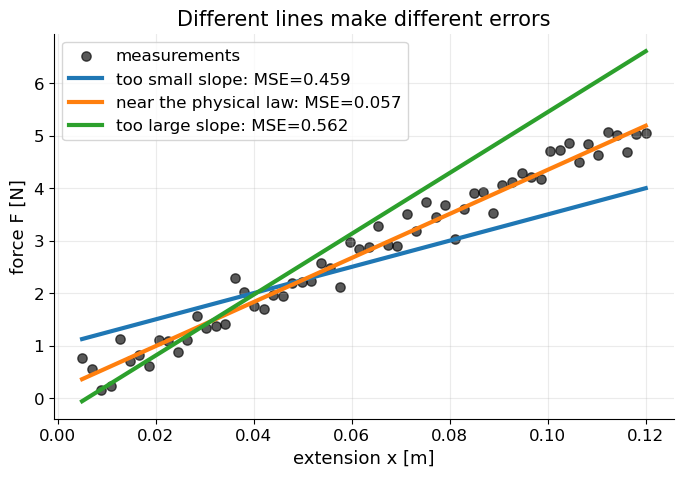

In [57]:
def model_prediction(x, w, b):
    return w * x + b            

# Three candidate models with different parameters w, b, and their descriptions
candidate_models = [
    (25.0, 1.0, "too small slope"),
    (42.0, 0.15, "near the physical law"),
    (58.0, -0.35, "too large slope"),
]

fig, ax = plt.subplots()
ax.scatter(x, y, s=45, color="black", alpha=0.65, label="measurements")

for w, b, name in candidate_models:
    y_hat = model_prediction(x, w, b)
    mse = torch.mean((y_hat - y)**2).item()
    ax.plot(x, y_hat, linewidth=3, label=f"{name}: MSE={mse:.3f}")

ax.set_title("Different lines make different errors")
ax.set_xlabel("extension x [m]")
ax.set_ylabel("force F [N]")
ax.legend()
plt.show()


## 3. Loss function: how good or bad is a model?

For each measurement at $x_i$ we define the **residual** between the prediction of the model $\hat y_i$ and the actual value $y_i$.

$$
r_i = \hat y_i - y_i.
$$

For linear regression, the standard choice for the **loss** $L(w,b)$, which is a measure of the total error of the model, is the **mean squared error** $\mathrm{MSE}$.

Why square the residuals?

1. positive and negative errors do not cancel,
2. large errors are punished more strongly,
3. the function is smooth and easy to differentiate.


### Visualize residuals

In the following plot, we construct a model by hand and show each residual as the vertical distance between the prediction of the model and the actual measurement. The MSE is the average of the squared residuals, so large vertical errors contribute strongly to the loss. The code draws one residual segment for every measurement.


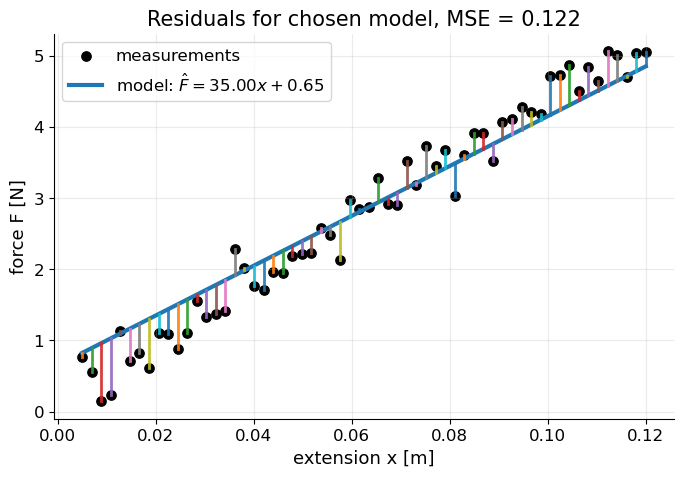

In [58]:
# Pick one candidate model and show its residuals
w_demo, b_demo = 35.0, 0.65
y_demo = model_prediction(x, w_demo, b_demo)

fig, ax = plt.subplots()
ax.scatter(x, y, s=45, color="black", label="measurements")
ax.plot(x, y_demo, linewidth=3, label=fr"model: $\hat F={w_demo:.2f}x+{b_demo:.2f}$")

# Draw one residual segment for every measurement
for xi, yi, yhi in zip(x, y, y_demo):
    ax.plot([xi.item(), xi.item()], [yi.item(), yhi.item()], linewidth=2, alpha=0.9)

mse_demo = torch.mean((y_demo - y)**2).item()
ax.set_title(f"Residuals for chosen model, MSE = {mse_demo:.3f}")
ax.set_xlabel("extension x [m]")
ax.set_ylabel("force F [N]")
ax.legend()
plt.show()


## 4. Classical least squares solution

Because the model is linear in its parameters, there is a classical numerical linear algebra solution.

Introduce the design matrix $\tilde{\mathbf X}$ with a column of ones and the parameter vector $\boldsymbol{\theta}$:

$$
\tilde{\mathbf X}=
\begin{bmatrix}
x_1 & 1\\
x_2 & 1\\
\vdots & \vdots\\
x_n & 1
\end{bmatrix},
\qquad
\boldsymbol{\theta}=
\begin{bmatrix}w\\b\end{bmatrix}.
$$

Then the vector of predictions is

$$
\hat{\mathbf y}=\tilde{\mathbf X}\boldsymbol{\theta}.
$$

The least-squares problem is calculating the optimal parameters $\boldsymbol{\theta}^*$ that minimize the sum of squares of all residuals.

$$
\boldsymbol{\theta}^* = \arg\min_{\boldsymbol{\theta}}
\left\|\hat{\mathbf y}-\mathbf y\right\|_2^2,
$$
where  $\|\mathbf{r}\|_2=\sqrt{r_1^2+r_2^2+\cdots+r_n^2}$ is the 2-norm. 

When $\tilde{\mathbf X}^{\top}\tilde{\mathbf X}$ is invertible, a closed-form solution to this problem is obtained as
$$
\boldsymbol{\theta}^*=\left(\tilde{\mathbf{X}}^{\top} \tilde{\mathbf{X}}\right)^{-1} \tilde{\mathbf{X}}^{\top} \mathbf{y}
$$

In PyTorch, we can use `torch.linalg.lstsq` to calculate the optimal parameters $\boldsymbol{\theta}^*$.


Least-squares slope       w = 42.4771 N/m
Least-squares intercept   b = 0.1395 N


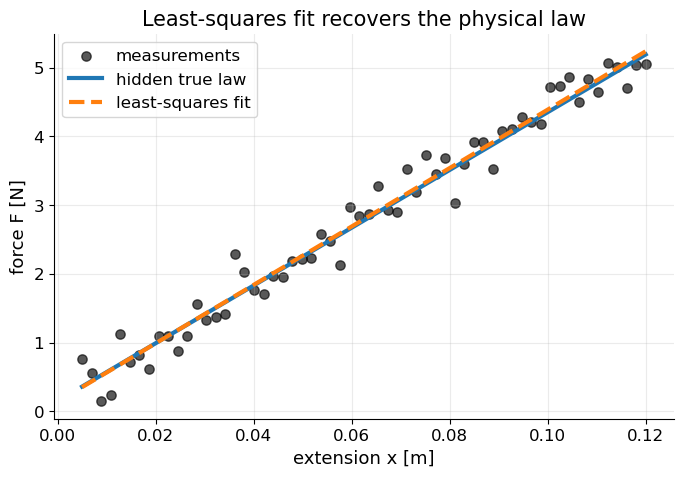

In [59]:
X_design = torch.cat([x, torch.ones_like(x)], dim=1)  # [x, 1]
solution = torch.linalg.lstsq(X_design, y).solution
w_lstsq, b_lstsq = solution[0, 0], solution[1, 0]

print(f"Least-squares slope       w = {w_lstsq.item():.4f} N/m")
print(f"Least-squares intercept   b = {b_lstsq.item():.4f} N")

fig, ax = plt.subplots()
ax.scatter(x, y, s=45, color="black", alpha=0.65, label="measurements")
ax.plot(x, true_k*x + true_b, linewidth=3, label="hidden true law")
ax.plot(x, model_prediction(x, w_lstsq, b_lstsq), "--", linewidth=3, label="least-squares fit")
ax.set_title("Least-squares fit recovers the physical law")
ax.set_xlabel("extension x [m]")
ax.set_ylabel("force F [N]")
ax.legend()
plt.show()


## 5. Same problem, neural-network style: gradient descent

Deep learning usually does not solve a closed-form linear algebra problem. It **minimizes a loss iteratively**.

For linear regression,

$$
L(w,b)=\frac{1}{n}\sum_{i=1}^n(wx_i+b-y_i)^2.
$$

The gradients are

$$
\frac{\partial L}{\partial w}
=\frac{2}{n}\sum_{i=1}^n x_i(wx_i+b-y_i),
$$

$$
\frac{\partial L}{\partial b}
=\frac{2}{n}\sum_{i=1}^n(wx_i+b-y_i).
$$

**Gradient descent** updates the parameters by

$$
w \leftarrow w - \eta\frac{\partial L}{\partial w},
\qquad
b \leftarrow b - \eta\frac{\partial L}{\partial b},
$$

where $\eta$ is the learning rate.


### Check gradients with autograd

Gradient descent needs the derivatives of the loss with respect to the trainable parameters $w$ and $b$:

$$
\frac{\partial L}{\partial w},
\qquad
\frac{\partial L}{\partial b}.
$$

PyTorch can compute these derivatives automatically. Setting `requires_grad=True` tells PyTorch to track operations involving `w` and `b`. After computing the loss, `loss.backward()` applies backpropagation and stores the derivatives in `w.grad` and `b.grad`.

For this simple model, we can also compute the gradients by hand. The cell below compares the manual formulas with PyTorch autograd at one arbitrary parameter choice.


In [60]:
# Compare manual gradients with PyTorch autograd at one arbitrary point
w = torch.tensor(0.10, requires_grad=True)
b = torch.tensor(1.00, requires_grad=True)

loss = torch.mean((model_prediction(x, w, b) - y)**2)
loss.backward()

with torch.no_grad():
    residuals = model_prediction(x, w, b) - y
    manual_dw = 2 * torch.mean(x * residuals)
    manual_db = 2 * torch.mean(residuals)

print(f"Autograd dL/dw = {w.grad.item(): .6f} | manual dL/dw = {manual_dw.item(): .6f}")
print(f"Autograd dL/db = {b.grad.item(): .6f} | manual dL/db = {manual_db.item(): .6f}")


Autograd dL/dw = -0.320078 | manual dL/dw = -0.320078
Autograd dL/db = -3.576093 | manual dL/db = -3.576093


### Train with full-batch gradient descent

Now we let the computer improve the parameters instead of choosing them by hand. Full-batch gradient descent uses the entire dataset to compute one loss value and one pair of gradients at each iteration. Because it sees all available data, each iteration is thus one **epoch**.

The function starts from initial guesses `w0` and `b0`. At every epoch it:

1. computes predictions,
2. computes the MSE loss,
3. calls `loss.backward()` to compute gradients,
4. updates $w$ and $b$,
5. resets the gradients before the next epoch.

The learning rate `lr` controls the step size. The list `path` stores the values of $w$, $b$, and the loss during training so that we can plot the optimization path later.

The update is wrapped in `torch.no_grad()` because the parameter update itself should not become part of the computation graph.


In [61]:
# Hyperparameters for gradient descent
lr = 0.8
epochs = 2000
w0 = -5.0
b0 = 1.80

# Define training loop using full-batch gradient descent 
def train_full_batch_gd(x, y, lr, epochs, w0, b0):
    w = torch.tensor(float(w0), requires_grad=True)     # initialize w with gradient tracking
    b = torch.tensor(float(b0), requires_grad=True)     # initialize b with gradient tracking
    path = []

    for epoch in range(epochs):
        y_hat = model_prediction(x, w, b)   # compute model predictions for all training points
        loss = torch.mean((y_hat - y)**2)   # compute the mean squared error loss over the whole training set
        loss.backward()                     # compute gradients dL/dw and dL/db

        with torch.no_grad():
            path.append((w.item(), b.item(), loss.item()))
            w -= lr * w.grad                # update parameters using the gradients and learning rate
            b -= lr * b.grad
            w.grad.zero_()                  # reset gradients to zero before the next iteration
            b.grad.zero_()

    return w.detach(), b.detach(), np.array(path)

# Train the model 
w_gd, b_gd, path = train_full_batch_gd(x, y, lr, epochs, w0, b0)

# Print the results
print(f"Gradient descent slope       w = {w_gd.item():.4f} N/m")
print(f"Gradient descent intercept   b = {b_gd.item():.4f} N")
print(f"Estimated spring constant    k = {w_gd.item():.2f} N/m")
print(f"Final MSE                    L = {path[-1, 2]:.5f}")


Gradient descent slope       w = 41.2270 N/m
Gradient descent intercept   b = 0.2177 N
Estimated spring constant    k = 41.23 N/m
Final MSE                    L = 0.05865


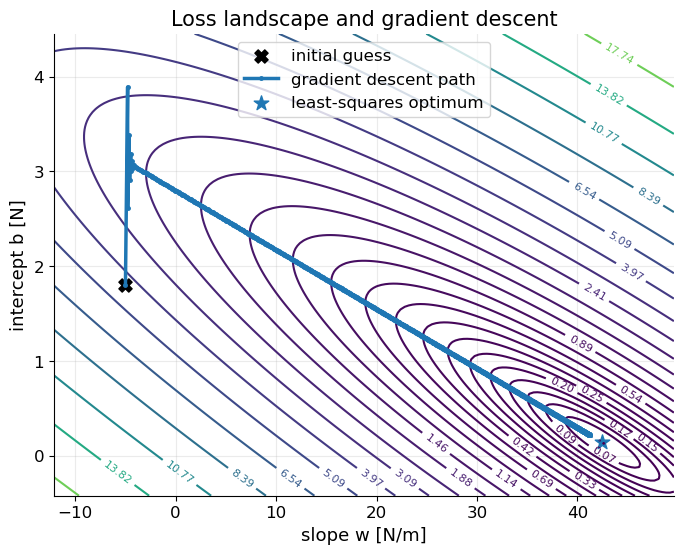

In [62]:
# Plot the loss surface and the path followed by gradient descent
w_plot_values = np.concatenate([path[:, 0], [w_lstsq.item()]])
b_plot_values = np.concatenate([path[:, 1], [b_lstsq.item()]])

w_padding = max(0.15 * (w_plot_values.max() - w_plot_values.min()), 5.0)
b_padding = max(0.15 * (b_plot_values.max() - b_plot_values.min()), 0.50)

w_values = torch.linspace(float(w_plot_values.min() - w_padding), float(w_plot_values.max() + w_padding), 160)
b_values = torch.linspace(float(b_plot_values.min() - b_padding), float(b_plot_values.max() + b_padding), 160)
W, B = torch.meshgrid(w_values, b_values, indexing="xy")

# Broadcast to compute the MSE at every point of the grid
Y_hat_grid = W[..., None] * x.flatten() + B[..., None]
Loss_grid = torch.mean((Y_hat_grid - y.flatten())**2, dim=-1)

fig, ax = plt.subplots(figsize=(8, 6))
levels = np.geomspace(Loss_grid.min().item() + 1e-4, Loss_grid.max().item(), 25)
cs = ax.contour(W.numpy(), B.numpy(), Loss_grid.numpy(), levels=levels)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

ax.scatter([path[0, 0]], [path[0, 1]], s=90, marker="X", color="black", label="initial guess")
ax.plot(path[:, 0], path[:, 1], marker="o", markersize=2.5, linewidth=2.5, label="gradient descent path")
ax.scatter([w_lstsq.item()], [b_lstsq.item()], s=120, marker="*", label="least-squares optimum")
ax.set_title("Loss landscape and gradient descent")
ax.set_xlabel("slope w [N/m]")
ax.set_ylabel("intercept b [N]")
ax.legend()
plt.show()


### Interactive loss landscape

The contour plot shows level curves of the loss. The same information can be viewed as a three-dimensional surface, where the horizontal axes are the parameters $w$ and $b$, and the vertical axis is the MSE loss. Plotly creates an interactive surface that can be rotated, zoomed, and inspected directly in the notebook.


In [63]:
import plotly.graph_objects as go

fig = go.Figure()

loss_lstsq = torch.mean((model_prediction(x, w_lstsq, b_lstsq) - y)**2).item()

fig.add_trace(
    go.Surface(
        x=W.numpy(),
        y=B.numpy(),
        z=Loss_grid.numpy(),
        colorscale="Viridis",
        opacity=0.85,
        name="MSE loss",
        showscale=True,
    )
)

fig.add_trace(
    go.Scatter3d(
        x=path[:, 0],
        y=path[:, 1],
        z=path[:, 2],
        mode="lines",
        line=dict(color="black", width=6),
        name="gradient descent path",
    )
)

fig.add_trace(
    go.Scatter3d(
        x=[w_lstsq.item()],
        y=[b_lstsq.item()],
        z=[loss_lstsq],
        mode="markers",
        marker=dict(color="red", size=6),
        name="least-squares optimum",
    )
)

fig.update_layout(
    title="Interactive loss landscape",
    scene=dict(
        xaxis_title="slope w [N/m]",
        yaxis_title="intercept b [N]",
        zaxis_title="MSE loss",
    ),
    width=850,
    height=650,
)

fig.show()


### Inspect the full-batch training curve

This plot shows the MSE loss after each full-batch gradient descent update. Because every update uses the entire dataset, the curve is usually smooth. The vertical axis is shown on a logarithmic scale so that the early rapid decrease and the later slower improvement are both visible.


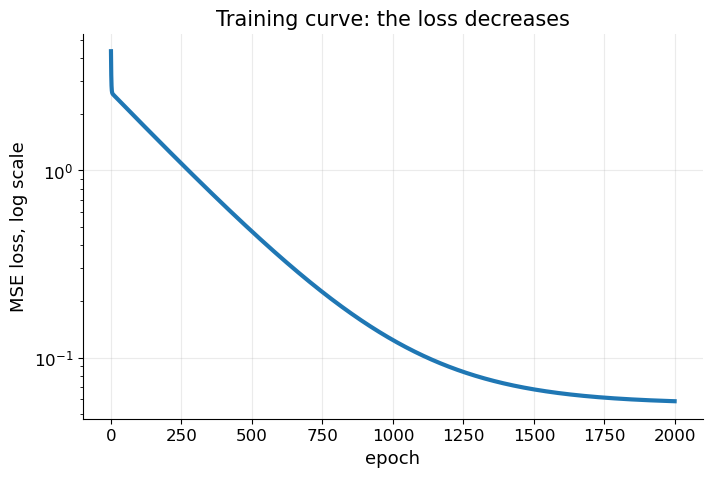

In [64]:
fig, ax = plt.subplots()
ax.plot(path[:, 2], linewidth=3)
ax.set_yscale("log")
ax.set_title("Training curve: the loss decreases")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss, log scale")
plt.show()

### Explore the learning rate $\eta$

The learning rate $\eta$ controls how large each gradient descent step is. If $\eta$ is too small, training is stable but slow. If $\eta$ is too large, the updates can overshoot the minimum and the loss may grow instead of shrink.

The next cell trains the same model several times with different learning rates, while keeping the same starting point $(w_0,b_0)$ and number of epochs.


eta=0.05: final finite MSE = 1.68273, w = 4.707, b = 2.503
eta= 0.2: final finite MSE = 0.47344, w = 23.365, b = 1.335
eta= 0.5: final finite MSE = 0.08417, w = 37.587, b = 0.445
eta= 0.8: final finite MSE = 0.05865, w = 41.227, b = 0.218
eta= 0.9: final finite MSE = 0.05758, w = 41.684, b = 0.189
eta=0.99: final finite MSE = 0.05718, w = 41.950, b = 0.172
eta= 1.0: final finite MSE = 57853066870784.00000, w = -477733.625, b = -7635733.500


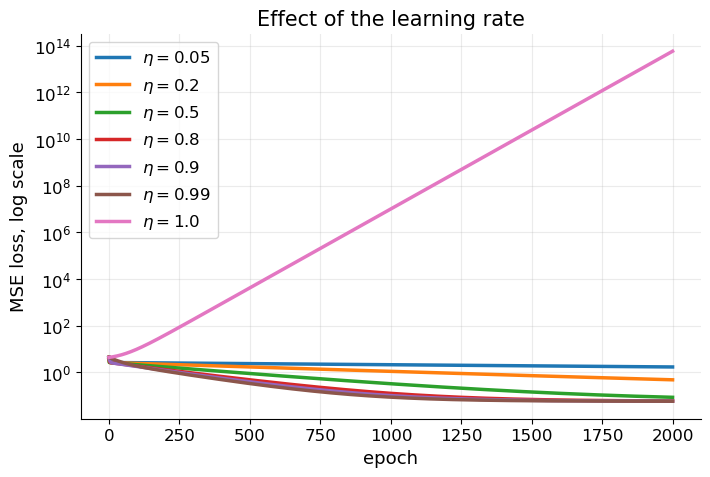

In [65]:
learning_rates = [0.05, 0.20, 0.5, 0.80, 0.9, 0.99, 1.0]
eta_epochs = 2000
eta_results = {}

fig, ax = plt.subplots()

for eta in learning_rates:
    w_eta, b_eta, path_eta = train_full_batch_gd(x, y, eta, eta_epochs, w0, b0)
    eta_results[eta] = (w_eta, b_eta, path_eta)

    losses = path_eta[:, 2]
    finite = np.isfinite(losses) & (losses > 0)
    ax.plot(
        np.arange(len(losses))[finite],
        losses[finite],
        linewidth=2.5,
        label=fr"$\eta={eta}$",
    )

    if finite.any():
        final_loss = losses[finite][-1]
        print(f"eta={eta:>4}: final finite MSE = {final_loss:.5f}, w = {w_eta.item():.3f}, b = {b_eta.item():.3f}")
    else:
        print(f"eta={eta:>4}: no finite positive losses")

ax.set_yscale("log")
ax.set_title("Effect of the learning rate")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss, log scale")
ax.legend()
plt.show()


### Explore the initial parameters $w_0$ and $b_0$

The initial values $w_0$ and $b_0$ are the starting point of gradient descent. In this notebook we choose values that are deliberately not optimal, so the optimization path is visible.

For linear regression with MSE loss, the loss surface is convex. This means that, with a stable learning rate, different starting points should move toward the same optimum. The starting point mostly changes the path and how long convergence takes.


not optimal, used above: start=(-5.0, 1.8) -> w=41.227 N/m, b=0.218 N, final MSE=0.05865
            zero start: start=(0.0, 0.0) -> w=41.361 N/m, b=0.209 N, final MSE=0.05828
     large slope start: start=(80.0, -1.0) -> w=43.465 N/m, b=0.078 N, final MSE=0.05798


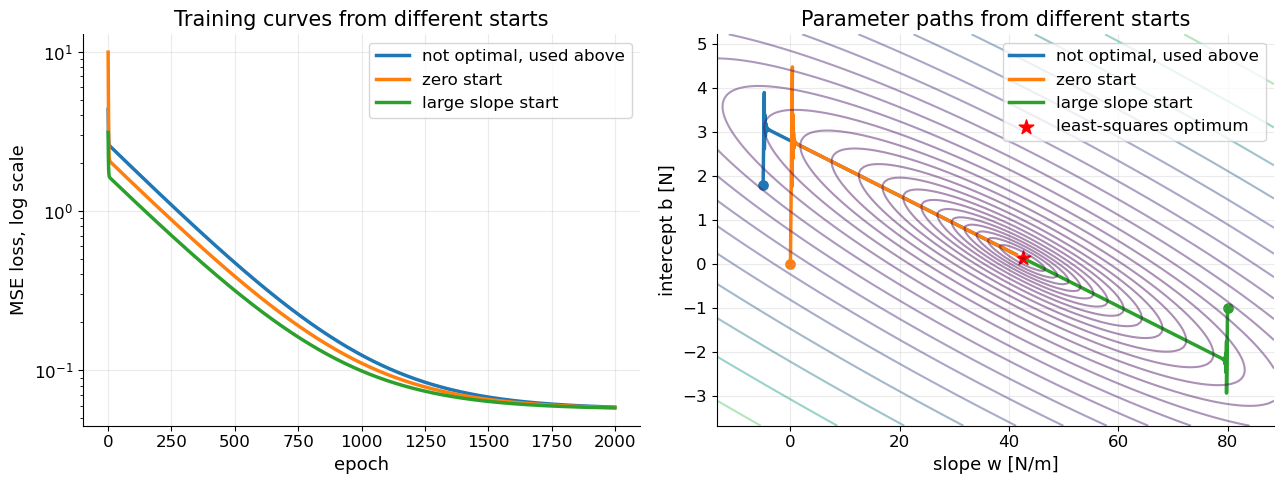

In [66]:
initial_parameters = [
    (-5.0, 1.80, "not optimal, used above"),
    (0.0, 0.00, "zero start"),
    (80.0, -1.00, "large slope start"),
]

init_lr = 0.8
init_epochs = 2000
init_results = []

for start_w, start_b, label in initial_parameters:
    w_start, b_start, path_start = train_full_batch_gd(x, y, init_lr, init_epochs, start_w, start_b)
    init_results.append((start_w, start_b, label, w_start, b_start, path_start))

    print(
        f"{label:>22}: start=({start_w:.1f}, {start_b:.1f}) "
        f"-> w={w_start.item():.3f} N/m, b={b_start.item():.3f} N, "
        f"final MSE={path_start[-1, 2]:.5f}"
    )

# Build a contour window that includes all starting points and paths.
w_init_values = np.concatenate([result[5][:, 0] for result in init_results] + [[w_lstsq.item()]])
b_init_values = np.concatenate([result[5][:, 1] for result in init_results] + [[b_lstsq.item()]])

w_init_padding = max(0.10 * (w_init_values.max() - w_init_values.min()), 5.0)
b_init_padding = max(0.10 * (b_init_values.max() - b_init_values.min()), 0.50)

w_init_grid = torch.linspace(float(w_init_values.min() - w_init_padding), float(w_init_values.max() + w_init_padding), 160)
b_init_grid = torch.linspace(float(b_init_values.min() - b_init_padding), float(b_init_values.max() + b_init_padding), 160)
W_init, B_init = torch.meshgrid(w_init_grid, b_init_grid, indexing="xy")
Loss_init = torch.mean((W_init[..., None] * x.flatten() + B_init[..., None] - y.flatten())**2, dim=-1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for start_w, start_b, label, w_start, b_start, path_start in init_results:
    axes[0].plot(path_start[:, 2], linewidth=2.5, label=label)
    axes[1].plot(path_start[:, 0], path_start[:, 1], linewidth=2.5, label=label)
    axes[1].scatter([path_start[0, 0]], [path_start[0, 1]], s=45)

axes[0].set_yscale("log")
axes[0].set_title("Training curves from different starts")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE loss, log scale")
axes[0].legend()

init_levels = np.geomspace(Loss_init.min().item() + 1e-4, Loss_init.max().item(), 25)
axes[1].contour(W_init.numpy(), B_init.numpy(), Loss_init.numpy(), levels=init_levels, alpha=0.45)
axes[1].scatter([w_lstsq.item()], [b_lstsq.item()], s=120, marker="*", color="red", label="least-squares optimum")
axes[1].set_title("Parameter paths from different starts")
axes[1].set_xlabel("slope w [N/m]")
axes[1].set_ylabel("intercept b [N]")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Input normalization

A common machine-learning preprocessing step is to normalize the input, using e.g. the mean value and standard deviation of the input values:

$$
\tilde{x} = \frac{x-\mu_x}{s_x}.
$$

Here $\mu_x$ is the mean input value,

$$
\mu_x = \frac{1}{n}\sum_{i=1}^n x_i,
$$

and $s_x$ is the sample standard deviation. This is what `torch.std()` computes by default:

$$
s_x = \sqrt{\frac{1}{n-1}\sum_{i=1}^n (x_i-\mu_x)^2}.
$$

The standard deviation is defined for any numerical dataset; it does not assume that the data are Gaussian.

We train the model

$$
\hat y = \tilde{w}\tilde{x} + \tilde{b}.
$$

To convert back to physical units,

$$
\hat y = \tilde{w}\frac{x-\mu_x}{s_x}+\tilde{b}
= \left(\frac{\tilde{w}}{s_x}\right)x + \left(\tilde{b} - \frac{\tilde{w}\mu_x}{s_x}\right).
$$

So the physical slope and intercept are

$$
w = \frac{\tilde{w}}{s_x},
\qquad
b = \tilde{b} - \frac{\tilde{w}\mu_x}{s_x}.
$$


In [67]:
x_mean = x.mean()
x_std = x.std()
x_norm = (x - x_mean) / x_std

print(f"mean(x) = {x_mean.item():.4f} m")
print(f"std(x)  = {x_std.item():.4f} m")
print(f"mean(x_norm) = {x_norm.mean().item():.3f}")
print(f"std(x_norm)  = {x_norm.std().item():.3f}")


mean(x) = 0.0625 m
std(x)  = 0.0340 m
mean(x_norm) = 0.000
std(x_norm)  = 1.000


### Compare training with and without normalization

To see why normalization helps, we compare two full-batch gradient descent runs with the same physical starting line and the same hyperparameters. Since our dataset has $n=60$ points, this is also the same as using a mini-batch size of 60.

The raw-input model starts from

$$
y = w_0x + b_0.
$$

The normalized-input model uses

$$
\hat y = \tilde{w}\tilde{x} + \tilde{b},
$$

but we choose $\tilde{w}_0$ and $\tilde{b}_0$ so that it represents the same physical starting line. Since

$$
\tilde{x} = \frac{x-\mu_x}{s_x},
$$

the matching normalized parameters are

$$
\tilde{w}_0 = w_0s_x,
\qquad
\tilde{b}_0 = b_0 + w_0\mu_x.
$$

This way, both runs start from the same line in physical units. Any difference in the training curves comes from the input scaling.


Same physical start:
  raw coordinates:        w0 = -5.000 N/m, b0 = 1.800 N
  normalized coordinates: w_norm0 = -0.170, b_norm0 = 1.488

Raw input final finite MSE:        0.05718
Normalized input final finite MSE: 0.05686
Normalized result in physical units: w = 42.477 N/m, b = 0.139 N


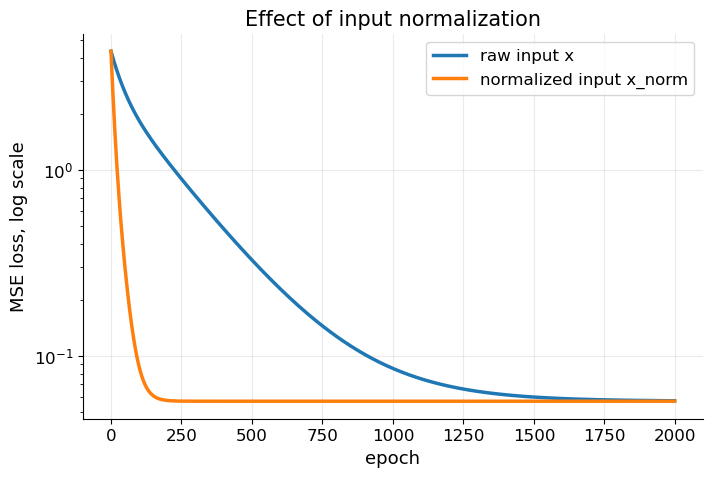

In [68]:
comparison_lr = 0.99
comparison_epochs = 2000
comparison_w0 = -5.0
comparison_b0 = 1.80

# Raw input: y_hat = w x + b
w_raw, b_raw, path_raw = train_full_batch_gd(
    x, y, comparison_lr, comparison_epochs, comparison_w0, comparison_b0
)

# Normalized input: y_hat = w_norm x_norm + b_norm
# Choose w_norm0 and b_norm0 so the initial physical line is the same.
w_norm0 = comparison_w0 * x_std.item()
b_norm0 = comparison_b0 + comparison_w0 * x_mean.item()

w_norm_compare = torch.tensor([[w_norm0]], requires_grad=True)
b_norm_compare = torch.tensor([b_norm0], requires_grad=True)
path_norm = []

for epoch in range(comparison_epochs):
    y_hat = x_norm @ w_norm_compare + b_norm_compare
    loss = torch.mean((y_hat - y)**2)
    loss.backward()

    with torch.no_grad():
        path_norm.append((w_norm_compare.item(), b_norm_compare.item(), loss.item()))
        w_norm_compare -= comparison_lr * w_norm_compare.grad
        b_norm_compare -= comparison_lr * b_norm_compare.grad
        w_norm_compare.grad.zero_()
        b_norm_compare.grad.zero_()

path_norm = np.array(path_norm)

w_norm_physical = w_norm_compare.item() / x_std.item()
b_norm_physical = b_norm_compare.item() - w_norm_compare.item() * x_mean.item() / x_std.item()

print("Same physical start:")
print(f"  raw coordinates:        w0 = {comparison_w0:.3f} N/m, b0 = {comparison_b0:.3f} N")
print(f"  normalized coordinates: w_norm0 = {w_norm0:.3f}, b_norm0 = {b_norm0:.3f}")
print()

raw_losses = path_raw[:, 2]
norm_losses = path_norm[:, 2]
raw_finite = np.isfinite(raw_losses) & (raw_losses > 0)
norm_finite = np.isfinite(norm_losses) & (norm_losses > 0)

if raw_finite.any():
    print(f"Raw input final finite MSE:        {raw_losses[raw_finite][-1]:.5f}")
else:
    print("Raw input produced no finite positive losses.")

if norm_finite.any():
    print(f"Normalized input final finite MSE: {norm_losses[norm_finite][-1]:.5f}")
    print(f"Normalized result in physical units: w = {w_norm_physical:.3f} N/m, b = {b_norm_physical:.3f} N")
else:
    print("Normalized input produced no finite positive losses.")

fig, ax = plt.subplots()
ax.plot(np.arange(len(raw_losses))[raw_finite], raw_losses[raw_finite], linewidth=2.5, label="raw input x")
ax.plot(np.arange(len(norm_losses))[norm_finite], norm_losses[norm_finite], linewidth=2.5, label="normalized input x_norm")
ax.set_yscale("log")
ax.set_title("Effect of input normalization")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss, log scale")
ax.legend()
plt.show()


### Explore the learning rate after normalization

Now we repeat the learning-rate experiment using the normalized input $\tilde{x}$. The physical starting line is kept the same for every run, but it is converted to normalized coordinates before training.

Because normalization changes the geometry of the loss surface, the same value of $\eta$ can behave very differently. Values that were slow or unstable in physical coordinates may become useful after scaling, while values that are too large can still overshoot.


eta=0.05: final finite MSE = 0.05686, w = 42.477 N/m, b = 0.139 N
eta= 0.2: final finite MSE = 0.05686, w = 42.477 N/m, b = 0.139 N
eta= 0.5: final finite MSE = 0.05686, w = 42.477 N/m, b = 0.139 N
eta= 0.8: final finite MSE = 0.05686, w = 42.477 N/m, b = 0.139 N
eta=0.99: final finite MSE = 0.05741, w = 42.476 N/m, b = 0.117 N
eta= 1.0: final finite MSE = 1.76467, w = 42.423 N/m, b = -1.164 N
eta=1.05: final finite MSE = 50899494216138752.00000, w = -14034834.358 N/m, b = -247292438.905 N


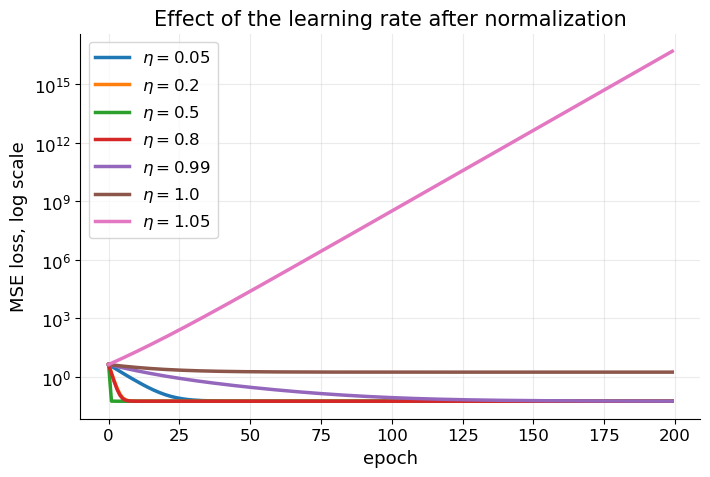

In [69]:
normalized_learning_rates = [0.05, 0.20, 0.50, 0.80, 0.99, 1.00, 1.05]
normalized_eta_epochs = 200
normalized_eta_results = {}


def train_normalized_full_batch_gd(x_norm, y, lr, epochs, w0_physical, b0_physical):
    # Same physical starting line, expressed in normalized coordinates.
    w_current = torch.tensor([[w0_physical * x_std.item()]], requires_grad=True)
    b_current = torch.tensor([b0_physical + w0_physical * x_mean.item()], requires_grad=True)
    path_current = []

    for epoch in range(epochs):
        y_hat = x_norm @ w_current + b_current
        loss = torch.mean((y_hat - y)**2)
        loss.backward()

        with torch.no_grad():
            path_current.append((w_current.item(), b_current.item(), loss.item()))
            w_current -= lr * w_current.grad
            b_current -= lr * b_current.grad
            w_current.grad.zero_()
            b_current.grad.zero_()

        if not np.isfinite(path_current[-1][2]):
            break

    w_physical_current = w_current.item() / x_std.item()
    b_physical_current = b_current.item() - w_current.item() * x_mean.item() / x_std.item()
    return w_physical_current, b_physical_current, np.array(path_current)


fig, ax = plt.subplots()

for eta in normalized_learning_rates:
    w_eta_norm, b_eta_norm, path_eta_norm = train_normalized_full_batch_gd(
        x_norm, y, eta, normalized_eta_epochs, comparison_w0, comparison_b0
    )
    normalized_eta_results[eta] = (w_eta_norm, b_eta_norm, path_eta_norm)

    losses = path_eta_norm[:, 2]
    finite = np.isfinite(losses) & (losses > 0)
    ax.plot(
        np.arange(len(losses))[finite],
        losses[finite],
        linewidth=2.5,
        label=fr"$\eta={eta}$",
    )

    if finite.any():
        final_loss = losses[finite][-1]
        print(
            f"eta={eta:>4}: final finite MSE = {final_loss:.5f}, "
            f"w = {w_eta_norm:.3f} N/m, b = {b_eta_norm:.3f} N"
        )
    else:
        print(f"eta={eta:>4}: no finite positive losses")

ax.set_yscale("log")
ax.set_title("Effect of the learning rate after normalization")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss, log scale")
ax.legend()
plt.show()


### Interactive normalized loss landscape

The previous plot compared how quickly the loss decreases. Here we look at the normalized model directly in parameter space. The horizontal axes are the normalized parameters $\tilde{w}$ and $\tilde{b}$, and the vertical axis is the MSE loss.

Because the input has been centered and scaled, the loss surface is usually less stretched than in physical coordinates. The black curve shows the gradient descent path from the same physical starting line used above.


In [70]:
import plotly.graph_objects as go

# Least-squares optimum expressed in normalized coordinates.
w_norm_opt = w_lstsq.item() * x_std.item()
b_norm_opt = b_lstsq.item() + w_lstsq.item() * x_mean.item()
loss_norm_opt = torch.mean((x_norm * w_norm_opt + b_norm_opt - y)**2).item()

finite_path_norm = path_norm[np.isfinite(path_norm[:, 2])]
w_min = min(finite_path_norm[:, 0].min(), w_norm_opt) - 0.4
w_max = max(finite_path_norm[:, 0].max(), w_norm_opt) + 0.4
b_min = min(finite_path_norm[:, 1].min(), b_norm_opt) - 0.4
b_max = max(finite_path_norm[:, 1].max(), b_norm_opt) + 0.4

w_norm_values = torch.linspace(w_min, w_max, 80)
b_norm_values = torch.linspace(b_min, b_max, 80)
W_norm_grid, B_norm_grid = torch.meshgrid(w_norm_values, b_norm_values, indexing="ij")

loss_norm_grid = torch.mean(
    (x_norm.reshape(-1, 1, 1) * W_norm_grid + B_norm_grid - y.reshape(-1, 1, 1))**2,
    dim=0,
)

# Plot fewer markers if many epochs are used, while keeping the full trajectory shape.
path_step = max(1, len(finite_path_norm) // 300)
path_to_plot = finite_path_norm[::path_step]
if not np.array_equal(path_to_plot[-1], finite_path_norm[-1]):
    path_to_plot = np.vstack([path_to_plot, finite_path_norm[-1]])

fig = go.Figure()

fig.add_trace(
    go.Surface(
        x=W_norm_grid.numpy(),
        y=B_norm_grid.numpy(),
        z=loss_norm_grid.numpy(),
        colorscale="Viridis",
        opacity=0.85,
        name="MSE loss",
        showscale=True,
    )
)

fig.add_trace(
    go.Scatter3d(
        x=path_to_plot[:, 0],
        y=path_to_plot[:, 1],
        z=path_to_plot[:, 2],
        mode="lines+markers",
        line=dict(color="black", width=6),
        marker=dict(color="black", size=3),
        name="gradient descent path",
    )
)

fig.add_trace(
    go.Scatter3d(
        x=[path_norm[0, 0]],
        y=[path_norm[0, 1]],
        z=[path_norm[0, 2]],
        mode="markers",
        marker=dict(color="orange", size=7),
        name="initial guess",
    )
)

fig.add_trace(
    go.Scatter3d(
        x=[w_norm_opt],
        y=[b_norm_opt],
        z=[loss_norm_opt],
        mode="markers",
        marker=dict(color="red", size=7),
        name="least-squares optimum",
    )
)

fig.update_layout(
    title="Interactive normalized loss landscape",
    scene=dict(
        xaxis_title="normalized slope w_tilde",
        yaxis_title="normalized intercept b_tilde [N]",
        zaxis_title="MSE loss",
    ),
    width=850,
    height=650,
)

fig.show()


## 7. Linear regression from scratch with mini-batches

So far, full-batch gradient descent used all $n$ measurements to compute each gradient update. A **mini-batch** is a smaller subset of the dataset, for example 10 measurements at a time.

Instead of computing one update from the whole dataset, mini-batch training repeatedly:

- shuffles the data,
- splits it into small batches,
- computes one update from each batch.

This is the standard training pattern in deep learning. It is usually faster for large datasets, uses less memory, and adds a little randomness to the optimization because each batch gives a slightly different estimate of the full gradient.

The basic mini-batch training loop has six steps:

1. shuffle the data,
2. take a mini-batch of data,
3. compute predictions,
4. compute loss,
5. compute gradients with `loss.backward()`,
6. update parameters.

This is the same skeleton used later for MLPs and CNNs.

To start using the standard ML terminology, **the input variables will be call features**. In this example, there is only one feature, the spring extension $x$. **The output variables** that the model tries to predict will be called **targets**. In this example, there is only one target, the measured force $F$.


In [ ]:
# This function randomly shuffles the data and creates batches of the specified size.
def data_batch(batch_size, features, targets):
    n = len(features)
    indices = torch.randperm(n)
    for i in range(0, n, batch_size):
        batch_indices = indices[i:i+batch_size]
        yield features[batch_indices], targets[batch_indices]

#Parameters in normalized coordinates: y_hat = w_norm x_norm + b_norm
# w_norm = torch.normal(0, 0.01, size=(1, 1), requires_grad=True)
# b_norm = torch.zeros(1, requires_grad=True)

w0_physical = -5.0
b0_physical = 1.80

w_norm = torch.tensor([[w0_physical * x_std.item()]], requires_grad=True)
b_norm = torch.tensor([b0_physical + w0_physical * x_mean.item()], requires_grad=True)

lr = 0.99 #0.99 # TRY 0.05
batch_size = 10
num_epochs = 25
loss_history = []

for epoch in range(num_epochs):
    for X_batch, y_target_batch in data_batch(batch_size, x_norm, y):
        y_hat = X_batch @ w_norm + b_norm
        loss = torch.mean((y_hat - y_target_batch)**2)
        loss.backward()

        with torch.no_grad():
            w_norm -= lr * w_norm.grad
            b_norm -= lr * b_norm.grad
            w_norm.grad.zero_()
            b_norm.grad.zero_()

    with torch.no_grad():
        epoch_loss = torch.mean((x_norm @ w_norm + b_norm - y)**2).item()
        loss_history.append(epoch_loss)

# Convert trained parameters back to physical units
w_physical = w_norm.item() / x_std.item()
b_physical = b_norm.item() - w_norm.item() * x_mean.item() / x_std.item()

print(f"Learned w_norm, b_norm in normalized coordinates: {w_norm.item():.4f}, {b_norm.item():.4f}")
print(f"Converted slope       w = {w_physical:.4f} N/m")
print(f"Converted intercept   b = {b_physical:.4f} N")
print(f"Estimated spring constant k = {w_physical:.2f} N/m")


Learned w_norm, b_norm in normalized coordinates: 1.4389, 2.7981
Converted slope       w = 42.2706 N/m
Converted intercept   b = 0.1562 N
Estimated spring constant k = 42.27 N/m


### Inspect the mini-batch training result

The training curve shows the MSE loss after each epoch. Because the parameters are updated from mini-batches, the curve can be a little noisier than full-batch gradient descent, but the overall trend should go down as the model improves.

The second plot compares the line learned by mini-batch gradient descent with the least-squares fit. For this linear problem, they should end up very close to each other.


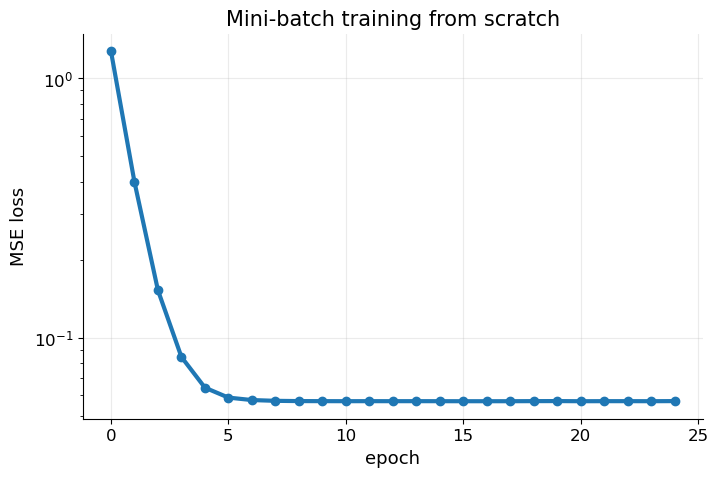

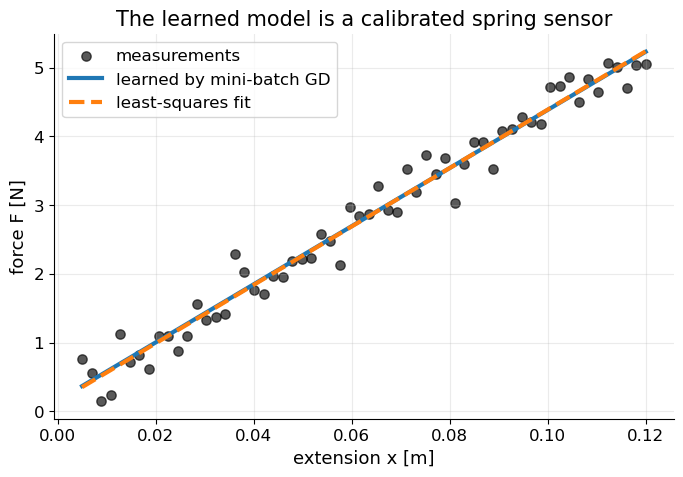

In [72]:
fig, ax = plt.subplots()
ax.plot(loss_history, marker="o", linewidth=3)
ax.set_yscale("log")
ax.set_title("Mini-batch training from scratch")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss")
plt.show()

fig, ax = plt.subplots()
ax.scatter(x, y, s=45, color="black", alpha=0.65, label="measurements")
ax.plot(x, model_prediction(x, w_physical, b_physical), linewidth=3, label="learned by mini-batch GD")
ax.plot(x, model_prediction(x, w_lstsq, b_lstsq), "--", linewidth=3, label="least-squares fit")
ax.set_title("The learned model is a calibrated spring sensor")
ax.set_xlabel("extension x [m]")
ax.set_ylabel("force F [N]")
ax.legend()
plt.show()


### Compare mini-batch sizes

Now we keep the same normalized model, the same learning rate, the same number of epochs, and the same physical starting line. The only thing we change is the mini-batch size.

Smaller batches make more updates per epoch, but each update is a noisier estimate of the full-data gradient. Larger batches make fewer updates per epoch, but each update is closer to the full-batch gradient. With an aggressive learning rate, small batches can sometimes fluctuate or even become unstable.


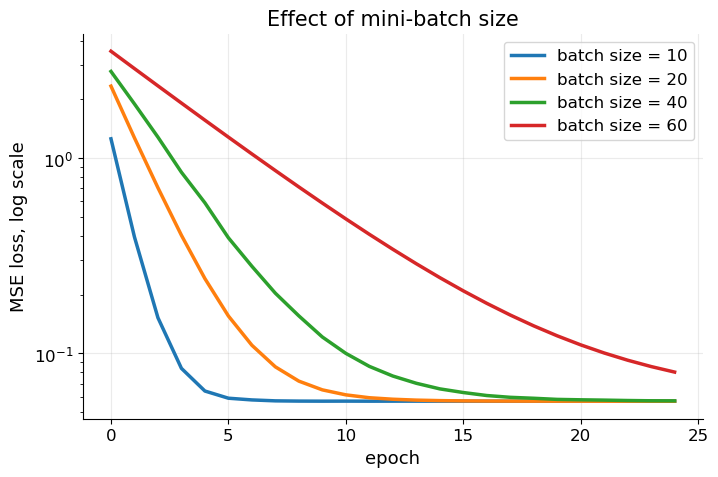

Final results after the same setup:
batch size 10: final finite MSE = 0.05686, w = 42.518 N/m, b = 0.136 N
batch size 20: final finite MSE = 0.05686, w = 42.456 N/m, b = 0.140 N
batch size 40: final finite MSE = 0.05710, w = 42.082 N/m, b = 0.156 N
batch size 60: final finite MSE = 0.08018, w = 38.907 N/m, b = 0.269 N


In [73]:
batch_sizes = [10, 20, 40, 60]
mini_batch_results = {}


def train_normalized_minibatch(batch_size, lr, num_epochs, w0_physical, b0_physical):
    # Same physical starting line, expressed in normalized coordinates.
    w_current = torch.tensor([[w0_physical * x_std.item()]], requires_grad=True)
    b_current = torch.tensor([b0_physical + w0_physical * x_mean.item()], requires_grad=True)
    history = []

    for epoch in range(num_epochs):
        for X_batch, y_target_batch in data_batch(batch_size, x_norm, y):
            y_hat = X_batch @ w_current + b_current
            loss = torch.mean((y_hat - y_target_batch)**2)
            loss.backward()

            with torch.no_grad():
                w_current -= lr * w_current.grad
                b_current -= lr * b_current.grad
                w_current.grad.zero_()
                b_current.grad.zero_()

        with torch.no_grad():
            epoch_loss = torch.mean((x_norm @ w_current + b_current - y)**2).item()
            history.append(epoch_loss)

        if not np.isfinite(history[-1]):
            break

    w_final = w_current.item() / x_std.item()
    b_final = b_current.item() - w_current.item() * x_mean.item() / x_std.item()
    return np.array(history), w_final, b_final


for batch_size_choice in batch_sizes:
    torch.manual_seed(SEED)
    history, w_final, b_final = train_normalized_minibatch(
        batch_size_choice, lr, num_epochs, w0_physical, b0_physical
    )
    mini_batch_results[batch_size_choice] = {
        "history": history,
        "w": w_final,
        "b": b_final,
    }

fig, ax = plt.subplots()
for batch_size_choice, result in mini_batch_results.items():
    history = result["history"]
    finite = np.isfinite(history) & (history > 0)
    ax.plot(
        np.arange(len(history))[finite],
        history[finite],
        linewidth=2.5,
        label=f"batch size = {batch_size_choice}",
    )

ax.set_yscale("log")
ax.set_title("Effect of mini-batch size")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss, log scale")
ax.legend()
plt.show()

print("Final results after the same setup:")
for batch_size_choice, result in mini_batch_results.items():
    history = result["history"]
    finite_history = history[np.isfinite(history)]
    if len(finite_history) == 0:
        print(f"batch size {batch_size_choice:2d}: no finite losses")
        continue
    print(
        f"batch size {batch_size_choice:2d}: "
        f"final finite MSE = {finite_history[-1]:.5f}, "
        f"w = {result['w']:.3f} N/m, "
        f"b = {result['b']:.3f} N"
    )


## 8. The concise PyTorch implementation

Now we write the same model using PyTorch building blocks:

- `TensorDataset` stores feature-target pairs,
- `DataLoader` creates shuffled mini-batches,
- `nn.Linear(1, 1)` represents

$$
\hat y = \tilde{w}\tilde{x} + \tilde{b},
$$

- `nn.MSELoss()` computes the mean squared error,
- `torch.optim.SGD` performs gradient descent.

This is the version students should recognize as the template for later neural networks.


In [74]:
dataset = TensorDataset(x_norm, y)
loader = DataLoader(dataset, batch_size=10, shuffle=True)

model = nn.Linear(in_features=1, out_features=1)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

loss_history_pytorch = []

for epoch in range(30):
    for X_batch, y_target_batch in loader:
        y_hat = model(X_batch)
        loss = loss_fn(y_hat, y_target_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        epoch_loss = loss_fn(model(x_norm), y).item()
        loss_history_pytorch.append(epoch_loss)

w_norm_nn = model.weight.item()
b_norm_nn = model.bias.item()
w_nn = w_norm_nn / x_std.item()
b_nn = b_norm_nn - w_norm_nn * x_mean.item() / x_std.item()

print("PyTorch nn.Linear parameters")
print(f"normalized coordinates: w_norm = {w_norm_nn:.4f}, b_norm = {b_norm_nn:.4f}")
print(f"physical coordinates:     w = {w_nn:.4f} N/m, b = {b_nn:.4f} N")
print(f"estimated spring constant: k = {w_nn:.2f} N/m")


PyTorch nn.Linear parameters
normalized coordinates: w_norm = 1.4444, b_norm = 2.7953
physical coordinates:     w = 42.4333 N/m, b = 0.1433 N
estimated spring constant: k = 42.43 N/m


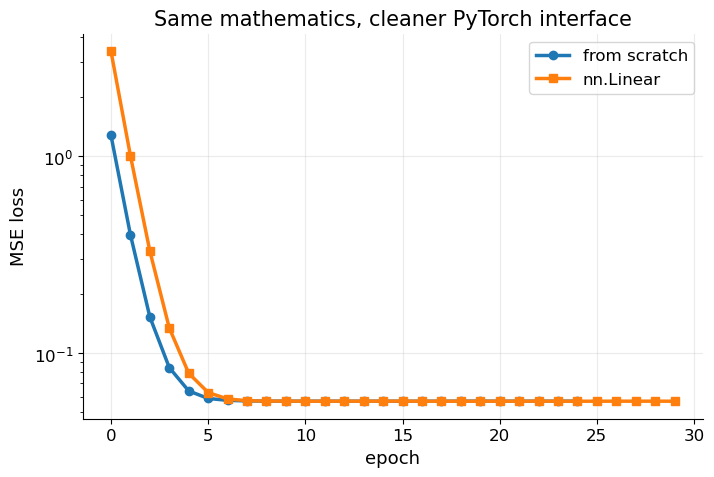

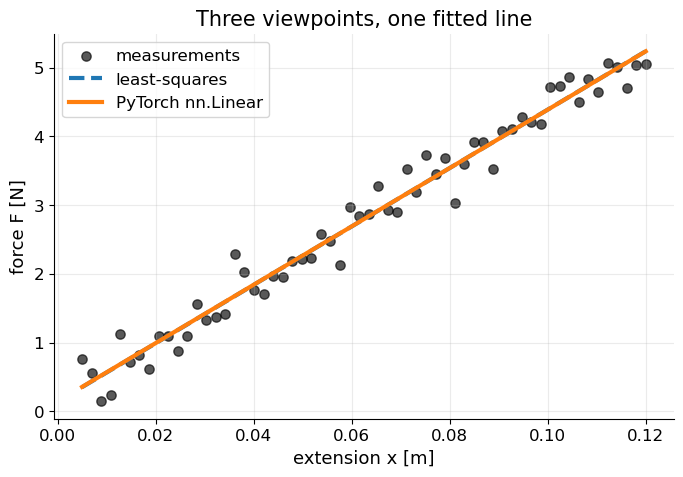

In [78]:
fig, ax = plt.subplots()
ax.set_yscale("log")
ax.plot(loss_history, marker="o", linewidth=2.5, label="from scratch")
ax.plot(loss_history_pytorch, marker="s", linewidth=2.5, label="nn.Linear")
ax.set_title("Same mathematics, cleaner PyTorch interface")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.scatter(x, y, s=45, color="black", alpha=0.65, label="measurements")
ax.plot(x, model_prediction(x, w_lstsq, b_lstsq), "--", linewidth=3, label="least-squares")
ax.plot(x, model_prediction(x, w_nn, b_nn), linewidth=3, label="PyTorch nn.Linear")
ax.set_title("Three viewpoints, one fitted line")
ax.set_xlabel("extension x [m]")
ax.set_ylabel("force F [N]")
ax.legend()
plt.show()


## 9. From one input to many inputs

The one-dimensional model was

$$
\hat y = wx + b.
$$

With $d$ input features, the model is

$$
\hat y = \sum_{j=1}^d w_jx_j + b
= \mathbf{x}^\top\mathbf{w}+b.
$$

Example: suppose a force sensor also drifts with temperature. A simple calibration model could be

$$
F = kx + c(T-T_0) + b + \epsilon.
$$

Now the input vector is

$$
\mathbf{x} = \begin{bmatrix}x \\ T-T_0\end{bmatrix}.
$$

Here $x$ is measured in meters and temperature differences are measured in kelvin.


In [76]:
# Two-feature calibration: extension and temperature drift
m = 200
extension = 0.12 * torch.rand(m, 1)            # m
temp_drift = 8 * (torch.rand(m, 1) - 0.5)      # K relative to T0

true_w_multi = torch.tensor([[42.0], [0.035]]) # [N/m, N/K]
true_b_multi = 0.15
X_multi = torch.cat([extension, temp_drift], dim=1)
y_multi = X_multi @ true_w_multi + true_b_multi + 0.18 * torch.randn(m, 1)

# Normalize each column
mu = X_multi.mean(dim=0, keepdim=True)
sigma = X_multi.std(dim=0, keepdim=True)
X_norm_multi = (X_multi - mu) / sigma

loader_multi = DataLoader(TensorDataset(X_norm_multi, y_multi), batch_size=32, shuffle=True)
model_multi = nn.Linear(2, 1)
opt = torch.optim.SGD(model_multi.parameters(), lr=0.08)
loss_fn = nn.MSELoss()

for epoch in range(80):
    for Xb, yb in loader_multi:
        loss = loss_fn(model_multi(Xb), yb)
        opt.zero_grad()
        loss.backward()
        opt.step()

# Convert weights from normalized coordinates back to physical coordinates
w_norm_multi = model_multi.weight.detach().reshape(2, 1)
b_norm_multi = model_multi.bias.detach().item()
w_multi_physical = w_norm_multi / sigma.reshape(2, 1)
b_multi_physical = b_norm_multi - torch.sum(w_norm_multi.reshape(-1) * mu.reshape(-1) / sigma.reshape(-1)).item()

print("True physical parameters:")
print(f"  extension coefficient      = {true_w_multi[0].item():.4f} N/m")
print(f"  temperature coefficient    = {true_w_multi[1].item():.4f} N/K")
print(f"  intercept                  = {true_b_multi:.4f} N")

print("\nLearned physical parameters:")
print(f"  extension coefficient      = {w_multi_physical[0].item():.4f} N/m")
print(f"  temperature coefficient    = {w_multi_physical[1].item():.4f} N/K")
print(f"  intercept                  = {b_multi_physical:.4f} N")


True physical parameters:
  extension coefficient      = 42.0000 N/m
  temperature coefficient    = 0.0350 N/K
  intercept                  = 0.1500 N

Learned physical parameters:
  extension coefficient      = 41.8601 N/m
  temperature coefficient    = 0.0354 N/K
  intercept                  = 0.1505 N


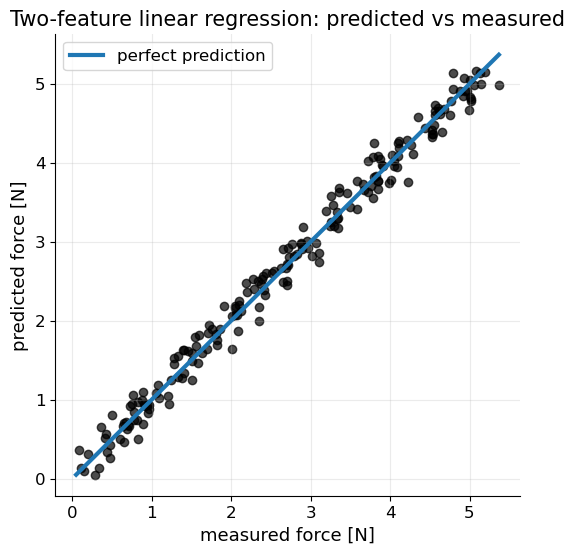

In [77]:
with torch.no_grad():
    y_pred_multi = model_multi(X_norm_multi)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_multi, y_pred_multi, color="black", alpha=0.7)
lims = [min(y_multi.min().item(), y_pred_multi.min().item()),
        max(y_multi.max().item(), y_pred_multi.max().item())]
ax.plot(lims, lims, linewidth=3, label="perfect prediction")
ax.set_title("Two-feature linear regression: predicted vs measured")
ax.set_xlabel("measured force [N]")
ax.set_ylabel("predicted force [N]")
ax.legend()
plt.show()


## 10. What students should remember

<div style="padding: 1rem; border-radius: 14px; background: #fff8e8; border: 1px solid #f1d08a;">
Linear regression is not just a statistics method. It is also the simplest trainable neural network layer.
</div>

The core concepts are:

1. **Model**

   $$
   \hat y = \mathbf{x}^\top\mathbf{w}+b.
   $$

2. **Loss**

   $$
   L=\frac{1}{n}\sum_i(\hat y_i-y_i)^2.
   $$

3. **Optimization**

   $$
   \theta \leftarrow \theta - \eta\nabla_\theta L.
   $$

4. **PyTorch training loop**

   ```python
   optimizer.zero_grad()
   loss.backward()
   optimizer.step()
   ```

5. **Physical interpretation**

   The learned slope is not just a number. In this example it directly estimates the spring constant in N/m.


## 11. Short exercises for students

### Exercise 1 — Change the noise
Increase `noise_sigma` from `0.22` to `0.60`. What happens to the fitted line? What happens to the uncertainty you would expect in the estimated spring constant $k$?

### Exercise 2 — Bad learning rate
In the full-batch gradient descent section, try `lr=0.05`, `lr=0.8`, and `lr=1.1`. Which one is too slow? Which one is unstable?

### Exercise 3 — Feature scaling
Train once with the raw extension values in meters and once with the normalized values `x_norm`. Which training curve is easier to optimize? Why does scaling help even though the physical model is the same?

### Exercise 4 — Mini-batch size
Try batch sizes `1`, `10`, and `60`. Compare the training curves.

### Exercise 5 — Add a useless feature
Add a random feature to `X_multi`. Does the model learn a coefficient close to zero? Why might this fail for small datasets or large noise?
